Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Automate Loan Approvals using Math-based Machine Learning")

Automate Loan Approvals using Math-based Machine Learning


Data Collection

In [2]:
def load_data(filename='train.csv'):
    try:
        df = pd.read_csv(filename)
        return df
    except FileNotFoundError:
        return None

df = load_data()

if df is not None:
    print(df.head())
    print(df.isnull().sum())

    Loan_ID Gender Married Dependents     Education Self_Employed  \
0  LP001002   Male      No          0      Graduate            No   
1  LP001003   Male     Yes          1      Graduate            No   
2  LP001005   Male     Yes          0      Graduate           Yes   
3  LP001006   Male     Yes          0  Not Graduate            No   
4  LP001008   Male      No          0      Graduate            No   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5849                0.0         NaN             360.0   
1             4583             1508.0       128.0             360.0   
2             3000                0.0        66.0             360.0   
3             2583             2358.0       120.0             360.0   
4             6000                0.0       141.0             360.0   

   Credit_History Property_Area Loan_Status  
0            0.96         Urban           Y  
1            0.89         Rural           N  
2            0.68   

Pre-processing & Feature Engineering (Normalization)

In [3]:
df['LoanAmount'] = df['LoanAmount'].fillna(df['LoanAmount'].mean())
df['Loan_Amount_Term'] = df['Loan_Amount_Term'].fillna(360.0)
df['Credit_History'] = df['Credit_History'].fillna(1.0)
df['Credit_History'] = df['Credit_History'].astype(float).clip(0, 1)
df['CoapplicantIncome'] = df['CoapplicantIncome'].fillna(0.0)

df['Property_Area_Code'] = df['Property_Area'].map({'Rural': 0, 'Semiurban': 1, 'Urban': 2})
df['Status'] = df['Loan_Status'].map({'Y': 1, 'N': 0})

df['Log_ApplicantIncome'] = np.log(df['ApplicantIncome'] + 1)
df['Log_LoanAmount'] = np.log(df['LoanAmount'] + 1)

features = ['Log_ApplicantIncome', 'CoapplicantIncome', 'Log_LoanAmount',
            'Loan_Amount_Term', 'Credit_History', 'Property_Area_Code']

X_raw = df[features].values
y = df['Status'].values

mu = np.mean(X_raw, axis=0)
sigma = np.std(X_raw, axis=0)
X_norm = (X_raw - mu) / sigma

print(X_norm.shape)

(614, 6)


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Model Development

In [4]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def compute_cost(X, y, w, b, lambda_reg):
    m = len(y)
    z = np.dot(X, w) + b
    predictions = sigmoid(z)

    error = -y * np.log(predictions + 1e-15) - (1 - y) * np.log(1 - predictions + 1e-15)
    reg_cost = (lambda_reg / (2 * m)) * np.sum(w ** 2)

    return np.mean(error) + reg_cost

def train_model(X, y, learning_rate=0.01, iterations=2000, lambda_reg=0.1):
    m, n = X.shape
    w = np.zeros(n)
    b = 0.0
    cost_history = []

    for i in range(iterations):
        z = np.dot(X, w) + b
        predictions = sigmoid(z)

        error = predictions - y
        dw = (1 / m) * np.dot(X.T, error) + (lambda_reg / m) * w
        db = (1 / m) * np.sum(error)

        w = w - learning_rate * dw
        b = b - learning_rate * db

        if i % 100 == 0:
            cost = compute_cost(X, y, w, b, lambda_reg)
            cost_history.append(cost)

    return w, b, cost_history

w_final, b_final, costs = train_model(X_norm, y, learning_rate=0.05, iterations=3000)

Performance Evaluation

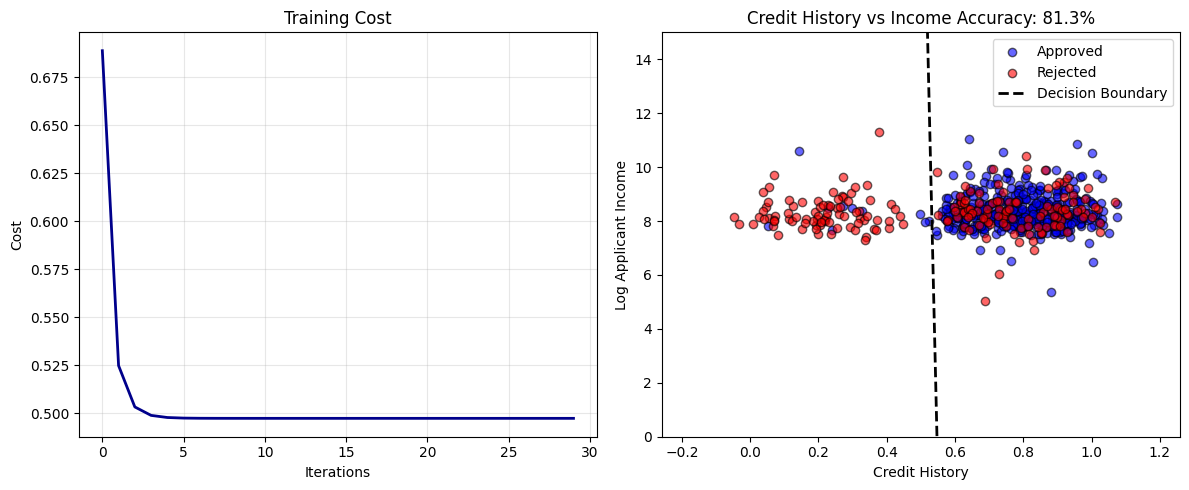

Final Model Accuracy: 81.27%


In [5]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(costs, color='darkblue', linewidth=2)
plt.title('Training Cost')
plt.xlabel('Iterations')
plt.ylabel('Cost')
plt.grid(True, alpha=0.3)

z_final = np.dot(X_norm, w_final) + b_final
y_pred_prob = sigmoid(z_final)
y_pred_class = (y_pred_prob >= 0.5).astype(int)
accuracy = np.mean(y_pred_class == y) * 100

plt.subplot(1, 2, 2)

jitter = np.random.normal(0, 0.05, len(df))

plt.scatter(df[df['Status']==1]['Credit_History'] + jitter[df['Status']==1],
            df[df['Status']==1]['Log_ApplicantIncome'],
            c='blue', alpha=0.6, edgecolors='k', label='Approved')

plt.scatter(df[df['Status']==0]['Credit_History'] + jitter[df['Status']==0],
            df[df['Status']==0]['Log_ApplicantIncome'],
            c='red', alpha=0.6, edgecolors='k', label='Rejected')

x_vals = np.linspace(df['Credit_History'].min()-0.2, df['Credit_History'].max()+0.2, 100)
idx_inc = 0
idx_cred = 4

norm_x = (x_vals - mu[idx_cred]) / sigma[idx_cred]
norm_y = (-b_final - w_final[idx_cred] * norm_x) / w_final[idx_inc]
y_vals = (norm_y * sigma[idx_inc]) + mu[idx_inc]

plt.plot(x_vals, y_vals, color='black', linewidth=2, linestyle='--', label='Decision Boundary')

plt.ylim(0, 15)

plt.title(f'Credit History vs Income Accuracy: {accuracy:.1f}%')
plt.xlabel('Credit History')
plt.ylabel('Log Applicant Income')
plt.legend()

plt.tight_layout()
plt.show()

print(f"Final Model Accuracy: {accuracy:.2f}%")

Innovation

In [7]:
import numpy as np
print("--- HDFC LOAN KIOSK ---")

try:
    inc = float(input("1. Monthly Income: "))
    co_inc = float(input("2. Co-applicant Income: "))
    loan = float(input("3. Loan Amount: "))
    term = float(input("4. Loan Term: "))
    cred = float(input("5. Credit History (0.00 to 1.00): "))
    prop = float(input("6. Property 0=Rural, 1=Semi, 2=Urban: "))

    log_inc = np.log(inc + 1)
    log_loan = np.log(loan + 1)

    user_vec = np.array([[log_inc, co_inc, log_loan, term, cred, prop]])
    user_norm = (user_vec - mu) / sigma

    z_score = np.dot(user_norm, w_final) + b_final
    prob = sigmoid(z_score)[0]

    if prob >= 0.7:
        print(f"\nDECISION: APPROVED ({prob*100:.2f}%)")
    else:
        print(f"\nDECISION: REJECTED ({prob*100:.2f}%)")

except Exception as e:
    print("Error:", e)

--- HDFC LOAN KIOSK ---
1. Monthly Income: 1200
2. Co-applicant Income: 23
3. Loan Amount: 455
4. Loan Term: 44
5. Credit History (0.00 to 1.00): .2
6. Property 0=Rural, 1=Semi, 2=Urban: 0

DECISION: REJECTED (21.03%)


Batch Prediction

In [8]:
test_df = pd.read_csv('test.csv')

test_df['LoanAmount'] = test_df['LoanAmount'].fillna(test_df['LoanAmount'].mean())
test_df['Loan_Amount_Term'] = test_df['Loan_Amount_Term'].fillna(360.0)
test_df['Credit_History'] = test_df['Credit_History'].fillna(1.0)
test_df['CoapplicantIncome'] = test_df['CoapplicantIncome'].fillna(0.0)

test_df['Property_Area_Code'] = test_df['Property_Area'].map({'Rural': 0, 'Semiurban': 1, 'Urban': 2})

test_df['Log_ApplicantIncome'] = np.log(test_df['ApplicantIncome'] + 1)
test_df['Log_LoanAmount'] = np.log(test_df['LoanAmount'] + 1)

X_test_raw = test_df[features].values
X_test_norm = (X_test_raw - mu) / sigma

z_test = np.dot(X_test_norm, w_final) + b_final
y_test_prob = sigmoid(z_test)
y_test_class = (y_test_prob >= 0.5).astype(int)

submission = pd.DataFrame({
    'Loan_ID': test_df['Loan_ID'],
    'Loan_Status': np.where(y_test_class == 1, 'Y', 'N')
})

print(submission.head())
submission.to_csv('submission.csv', index=False)

    Loan_ID Loan_Status
0  LP001015           Y
1  LP001022           Y
2  LP001031           Y
3  LP001035           Y
4  LP001051           Y
